In [1]:
import cv2
import matplotlib.pyplot as plt

In [2]:
#https://github.com/opencv/opencv/wiki/tensorflow-object-detection-api
config_file = 'config.pbtxt'
frozen_model = 'frozen_inference_graph.pb'

In [3]:
model = cv2.dnn_DetectionModel(frozen_model, config_file)

In [4]:
classLabels = []
file_name = 'labels.txt'
with open(file_name, 'rt') as fpt:
    classLabels = fpt.read().rstrip('\n').split('\n')#strips the last new line and split each new line for creating a list

In [5]:
print(classLabels)

['person', 'bicycle', 'car', 'motorbike', 'aeroplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'sofa', 'pottedplant', 'bed', 'diningtable', 'toilet', 'tvmonitor', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']


In [6]:
len(classLabels)

80

In [35]:
img = cv2.imread("test.jpg")

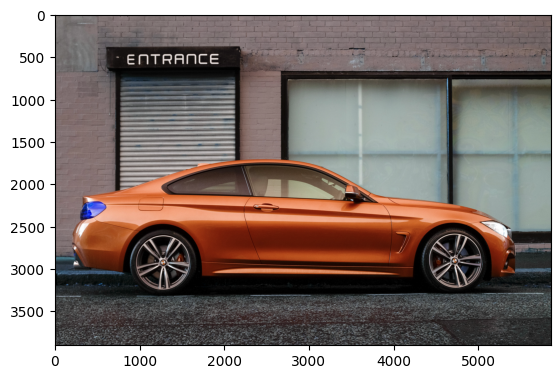

In [36]:
plt.imshow(img)#bgr for opencv

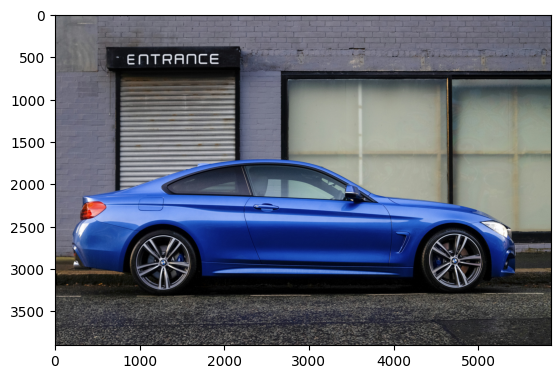

In [37]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

# model config

In [38]:
model.setInputSize(320,320) #resize input image to 320x320, before passing it to the model
model.setInputScale(1.0/127.5)# values are in the range of 0-255, by dividing by 127.5, the values will be in the range of 0 to 2
model.setInputMean((127.5,127.5,127.5)) #centres data range -1 to +1
model.setInputSwapRB(True) #bgr to rgb

< cv2.dnn.Model 0000020BBBACF190>

# object detection

In [39]:
ClassIndex, confidence, bbox = model.detect(img, confThreshold = 0.5) #50% confidence

In [40]:
print(ClassIndex)

[3]


In [47]:
#modify image
font_scale = 3.5
font = cv2.FONT_HERSHEY_SIMPLEX
for ClassInd, conf, boxes in zip(ClassIndex.flatten(), confidence.flatten(), bbox):
    cv2.rectangle(img, boxes, (0,255,0), 2)#blue rectangle color box
    cv2.putText(img, classLabels[ClassInd-1], (boxes[0]+10, boxes[1]+40), font, fontScale=font_scale, color = (0,0,255), thickness =4)

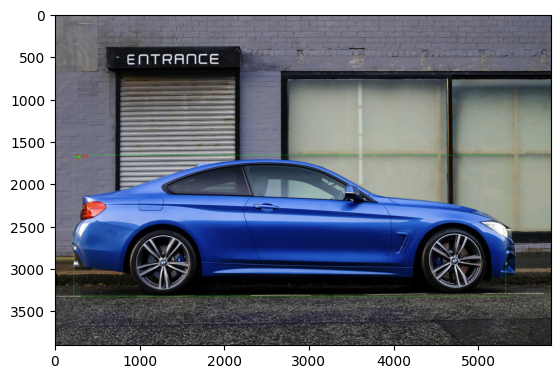

In [48]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))